# Volume experiment — Generalized accuracy (GACC) and classical accuracy (ACC)

For each of the four result sets (MLP/CNN × original/augmented data),
this notebook computes and plots:

- **GACC** = $\frac{\sum_i V_3(\boldsymbol{x}_i)}{\sum_i V_2(\boldsymbol{x}_i)}$ — generalised accuracy (ratio of total $V_3$ to total $V_2$ across all samples)
- **ACC** — classical accuracy of the quantised model on the same samples

Containment: $\Xi_{\text{base}} \supseteq \Xi_{\text{correct}}^b \supseteq \Xi_{\text{both}}^b$

## Setup

In [23]:
%load_ext autoreload
%autoreload 2

import copy, json, math, os, sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(ROOT))

from src.models.networks       import FashionMLP_Large, FashionCNN_Small
from src.quantization.quantize import quantize_model

DEVICE       = torch.device("cpu")
SAVE_PDF     = True
RESULTS_ROOT = ROOT / "results"
print("Project root:", ROOT)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes


## Helper functions

In [24]:
def load_records(results_dir):
    recs = []
    for f in sorted(Path(results_dir).glob("volumes_sample*.json")):
        with open(f) as fh:
            recs.append(json.load(fh))
    return recs


def compute_gacc(records, bits_grid):
    """GACC = sum_i V3(x_i) / sum_i V2(x_i), plus zero-count per bit."""
    def is_bad(v):
        return v is None or math.isnan(v) or v == 0.0

    sum_both    = {b: 0.0 for b in bits_grid}
    sum_correct = {b: 0.0 for b in bits_grid}
    n_zeros     = {b: 0   for b in bits_grid}

    for r in records:
        for b in bits_grid:
            wc  = r["widths_correct"][str(b)]
            wbo = r["widths_both"][str(b)]
            wc_val  = 0.0 if is_bad(wc)  else wc
            wbo_val = 0.0 if is_bad(wbo) else wbo
            if is_bad(wbo):
                n_zeros[b] += 1
            sum_correct[b] += wc_val
            sum_both[b]    += wbo_val

    return {
        "gacc":    np.array([
            sum_both[b] / sum_correct[b] if sum_correct[b] > 0 else np.nan
            for b in bits_grid
        ]),
        "n_zeros": [n_zeros[b] for b in bits_grid],
    }


def load_fp_model(model_type):
    """Load the full-precision FashionMLP_Large or FashionCNN_Small."""
    if model_type == "mlp":
        model = FashionMLP_Large()
        ckpt  = ROOT / "checkpoints" / "fashion_mlp_best.pth"
    else:
        model = FashionCNN_Small()
        ckpt  = ROOT / "checkpoints" / "fashion_cnn_best.pth"
    state = torch.load(ckpt, map_location=DEVICE, weights_only=True)
    model.load_state_dict(state)
    return model.eval().to(DEVICE)


def build_qmodels(fp_model, bits_grid):
    """Return {b: quantised_copy} for every b in bits_grid."""
    return {b: quantize_model(fp_model, bits=b).eval().to(DEVICE)
            for b in bits_grid}


@torch.no_grad()
def _predict(model, x):
    return int(model(x.unsqueeze(0).to(DEVICE)).argmax(dim=1).item())


def compute_acc(records, dataset, fp_model, qmodels):
    """
    For each sample_idx in records, fetch (x, c) from dataset and compute
    the fraction correctly classified by the fp model and each q-model.
    Returns {"fp": float, b: float, ...}
    """
    n   = len(records)
    cf  = 0
    cq  = {b: 0 for b in qmodels}
    for r in records:
        x, c = dataset[r["sample_idx"]]
        c = int(c)
        if _predict(fp_model, x) == c:
            cf += 1
        for b, qm in qmodels.items():
            if _predict(qm, x) == c:
                cq[b] += 1
    return {"fp": cf / n, **{b: cq[b] / n for b in qmodels}}

## Configurations

In [25]:
CONFIGS = [
    dict(
        label      = "MLP (original)",
        model_type = "mlp",
        results_dir= RESULTS_ROOT / "volumes_mlp",
        data_file  = "fashionMNIST_correct_mlp.pt",
    ),
    dict(
        label      = "MLP (augmented)",
        model_type = "mlp",
        results_dir= RESULTS_ROOT / "volumes_mlp_aug",
        data_file  = "fashionMNIST_augmented_mlp_seed42.pt",
    ),
    dict(
        label      = "CNN (original)",
        model_type = "cnn",
        results_dir= RESULTS_ROOT / "volumes_cnn",
        data_file  = "fashionMNIST_correct_cnn.pt",
    ),
    dict(
        label      = "CNN (augmented)",
        model_type = "cnn",
        results_dir= RESULTS_ROOT / "volumes_cnn_aug",
        data_file  = "fashionMNIST_augmented_cnn_seed42.pt",
    ),
]

## Load results, compute GACC and ACC

In [26]:
# Models are loaded once per model_type and reused across configs.
_fp_cache = {}
_qm_cache = {}

RESULTS = {}   # label -> dict of computed quantities

for cfg in CONFIGS:
    mtype = cfg["model_type"]
    label = cfg["label"]
    print(f"\n── {label} ──")

    # ── Results ──────────────────────────────────────────────────────
    recs      = load_records(cfg["results_dir"])
    bits_grid = sorted(int(b) for b in recs[0]["widths_both"].keys())
    print(f"  {len(recs)} samples  bits={bits_grid}")

    # ── GACC ─────────────────────────────────────────────────────────
    gacc_info = compute_gacc(recs, bits_grid)

    # ── Load model (once per model_type) ─────────────────────────────
    if mtype not in _fp_cache:
        _fp_cache[mtype] = load_fp_model(mtype)
        _qm_cache[mtype] = build_qmodels(_fp_cache[mtype], bits_grid)
        print(f"  Loaded {mtype.upper()} fp model + {len(bits_grid)} q-models")

    fp_model = _fp_cache[mtype]
    qmodels  = _qm_cache[mtype]

    # ── Classical accuracy ────────────────────────────────────────────
    dataset  = torch.load(ROOT / "data" / cfg["data_file"],
                          map_location=DEVICE, weights_only=False)
    acc_info = compute_acc(recs, dataset, fp_model, qmodels)
    print("  ACC  fp={fp:.4f}  ".format(**acc_info) +
          "  ".join(f"b{b}={acc_info[b]:.4f}" for b in bits_grid))

    RESULTS[label] = dict(
        model_type = mtype,
        n_samples  = len(recs),
        bits_grid  = bits_grid,
        gacc       = gacc_info["gacc"],
        n_zeros    = gacc_info["n_zeros"],
        acc        = acc_info,
    )

print("\nDone.")


── MLP (original) ──
  1999 samples  bits=[4, 6, 8, 10, 12, 16]
  Loaded MLP fp model + 6 q-models
  ACC  fp=1.0000  b4=0.9900  b6=0.9985  b8=0.9995  b10=1.0000  b12=1.0000  b16=1.0000

── MLP (augmented) ──
  2000 samples  bits=[4, 6, 8, 10, 12, 16]
  ACC  fp=1.0000  b4=0.9900  b6=0.9985  b8=0.9995  b10=0.9995  b12=1.0000  b16=1.0000

── CNN (original) ──
  2000 samples  bits=[4, 6, 8, 10, 12, 16]
  Loaded CNN fp model + 6 q-models
  ACC  fp=1.0000  b4=0.9395  b6=0.9950  b8=0.9985  b10=1.0000  b12=0.9995  b16=1.0000

── CNN (augmented) ──
  2000 samples  bits=[4, 6, 8, 10, 12, 16]
  ACC  fp=1.0000  b4=0.9395  b6=0.9950  b8=0.9985  b10=1.0000  b12=0.9995  b16=1.0000

Done.


## Summary table

In [27]:
for label, res in RESULTS.items():
    bg = res["bits_grid"]
    print(f"\n{label}  (n={res['n_samples']})")
    print(f"  {'bits':>5}  {'GACC':>10}  {'ACC':>10}  {'n_zeros':>8}")
    for i, b in enumerate(bg):
        print(f"  {b:5d}  {res['gacc'][i]:10.6f}  {res['acc'][b]:10.6f}  {res['n_zeros'][i]:8d}")


MLP (original)  (n=1999)
   bits        GACC         ACC   n_zeros
      4    0.999486    0.989995        10
      6    0.999998    0.998499         0
      8    1.000000    0.999500         0
     10    1.000000    1.000000         0
     12    1.000000    1.000000         0
     16    1.000000    1.000000         0

MLP (augmented)  (n=2000)
   bits        GACC         ACC   n_zeros
      4    0.999760    0.990000        10
      6    0.999999    0.998500         0
      8    1.000000    0.999500         0
     10    1.000000    0.999500         0
     12    1.000000    1.000000         0
     16    1.000000    1.000000         0

CNN (original)  (n=2000)
   bits        GACC         ACC   n_zeros
      4    0.997005    0.939500         9
      6    0.999974    0.995000         0
      8    0.999995    0.998500         0
     10    1.000000    1.000000         0
     12    1.000000    0.999500         0
     16    1.000000    1.000000         0

CNN (augmented)  (n=2000)
   bits     

## Plots — GACC and ACC vs bit-width

Saved to /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/figures/plot_gacc_acc_all.pdf


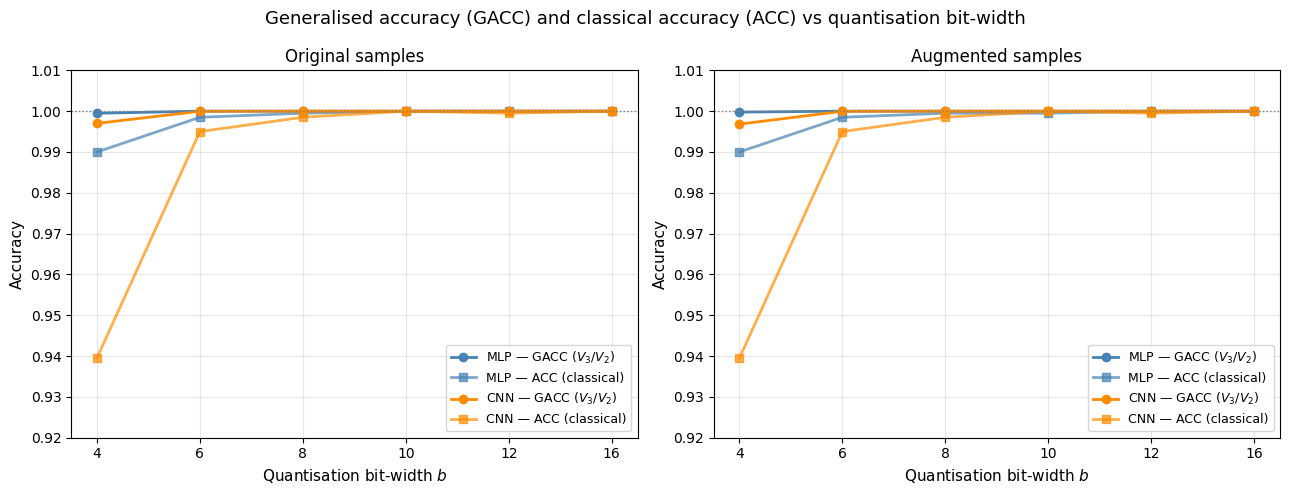

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
fig.suptitle(
    "Generalised accuracy (GACC) and classical accuracy (ACC) vs quantisation bit-width",
    fontsize=13
)

colors = {"mlp": "steelblue", "cnn": "darkorange"}

panels = [
    ("original",  axes[0], ["MLP (original)",  "CNN (original)"]),
    ("augmented", axes[1], ["MLP (augmented)", "CNN (augmented)"]),
]

for panel_title, ax, labels in panels:
    for label in labels:
        res      = RESULTS[label]
        mtype    = res["model_type"]
        bg       = res["bits_grid"]
        x        = np.arange(len(bg))
        acc_vals = np.array([res["acc"][b] for b in bg])
        col      = colors[mtype]

        ax.plot(x, res["gacc"], marker="o", linewidth=2, markersize=6,
                color=col, linestyle="-",
                label=f"{mtype.upper()} — GACC ($V_3/V_2$)")
        ax.plot(x, acc_vals,    marker="s", linewidth=2, markersize=6,
                color=col, linestyle="-", alpha=0.7,
                label=f"{mtype.upper()} — ACC (classical)")

    ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"{panel_title.capitalize()} samples", fontsize=12)
    ax.set_xlabel("Quantisation bit-width $b$", fontsize=11)
    ax.set_ylabel("Accuracy", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(bg)
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.92, 1.01)

plt.tight_layout()
if SAVE_PDF:
    path = RESULTS_ROOT / "figures" / "plot_gacc_acc_all.pdf"
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved to {path}")
plt.show()

In [36]:
print(RESULTS["MLP (original)"]["gacc"])
print(RESULTS["MLP (augmented)"]["gacc"])
print("")
print(RESULTS["CNN (original)"]["gacc"])
print(RESULTS["CNN (augmented)"]["gacc"])

[0.99948584 0.99999773 0.99999957 0.99999988 0.99999995 1.        ]
[0.99976048 0.9999994  0.9999996  0.99999988 0.99999995 1.        ]

[0.99700492 0.99997381 0.99999533 0.99999951 0.99999982 0.99999999]
[0.99681675 0.99997051 0.99999482 0.99999949 0.99999979 0.99999998]


## Single-config compatibility (for cells below)

The cells below (mean/std analysis, visual comparison) work on a single configuration.
Set `_COMPAT_LABEL` to whichever entry in `RESULTS` you want to explore.

In [7]:
_COMPAT_LABEL = "MLP (original)"   # change to any key in RESULTS

_cfg = next(c for c in CONFIGS if c["label"] == _COMPAT_LABEL)
MODEL_TYPE  = _cfg["model_type"]
RESULTS_DIR = _cfg["results_dir"]
_plot_tag   = MODEL_TYPE
records     = load_records(RESULTS_DIR)
bits_grid   = sorted(int(b) for b in records[0]["widths_both"].keys())

# Recompute accumulators expected by the cells below
def is_bad(v):
    return v is None or math.isnan(v) or v == 0.0

sum_base     = 0.0
sum_correct  = {b: 0.0 for b in bits_grid}
sum_both     = {b: 0.0 for b in bits_grid}
zero_both    = {b: [] for b in bits_grid}

for r in records:
    wb = r["width_base"]
    wb_val = 0.0 if is_bad(wb) else wb
    sum_base += wb_val
    for b in bits_grid:
        wc  = r["widths_correct"][str(b)]
        wbo = r["widths_both"][str(b)]
        wc_val  = 0.0 if is_bad(wc)  else wc
        wbo_val = 0.0 if is_bad(wbo) else wbo
        sum_correct[b] += wc_val
        if is_bad(wbo):
            zero_both[b].append(r["sample_idx"])
        sum_both[b] += wbo_val

print(f"Compatibility mode: {_COMPAT_LABEL}  ({len(records)} samples)")

Compatibility mode: MLP (original)  (1999 samples)


## Mean and std of widths per bit-width

width_base    : mean=39.8099  std=0.5713

  bits    mean_correct   std_correct     mean_both    std_both
     4         37.4592        2.7956       36.4399      2.8517
     6         39.2498        0.6767       38.2498      0.6768
     8         39.6673        0.5986       38.6672      0.5986
    10         39.7728        0.5787       38.7728      0.5787
    12         39.8012        0.5730       38.8012      0.5730
    16         39.8094        0.5714       38.8094      0.5714
Saved to /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/figures/plot_mean_std_widths_mlp.pdf


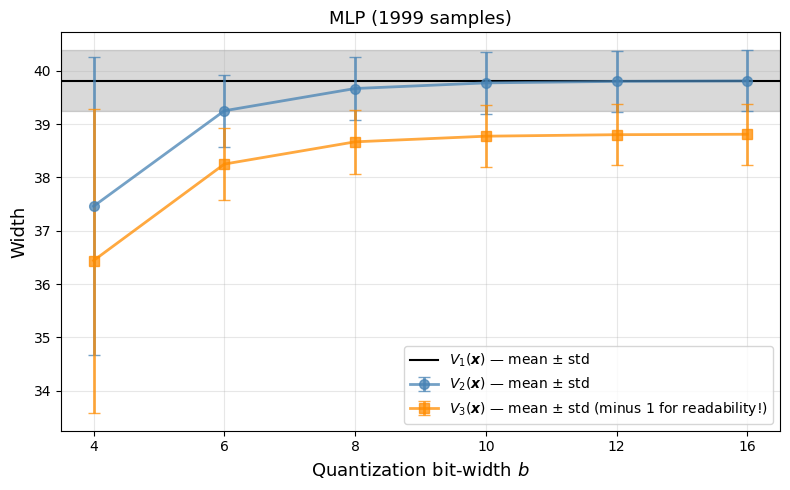

In [8]:
import numpy as np

# Collect per-sample arrays
arr_base    = np.array([r["width_base"] for r in records])
arr_correct = {b: np.array([r["widths_correct"][str(b)] for r in records]) for b in bits_grid}
arr_both    = {b: np.array([r["widths_both"][str(b)]    for r in records]) for b in bits_grid}

# Means and stds
mean_base = arr_base.mean();  std_base = arr_base.std()

mean_correct = np.array([arr_correct[b].mean() for b in bits_grid])
std_correct  = np.array([arr_correct[b].std()  for b in bits_grid])

mean_both    = np.array([arr_both[b].mean() for b in bits_grid]) - 1 # minus 1 for readability)
std_both     = np.array([arr_both[b].std()  for b in bits_grid])

print(f"width_base    : mean={mean_base:.4f}  std={std_base:.4f}")
print()
print(f"{'bits':>6}  {'mean_correct':>14}  {'std_correct':>12}  {'mean_both':>12}  {'std_both':>10}")
for i, b in enumerate(bits_grid):
    print(f"  {b:4d}  {mean_correct[i]:14.4f}  {std_correct[i]:12.4f}  {mean_both[i]:12.4f}  {std_both[i]:10.4f}")

# ------------------------------------------------------------------ #
# Plot: mean ± std of width_base, widths_correct, widths_both        #
# ------------------------------------------------------------------ #
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(bits_grid))

# width_base: constant across b — draw as horizontal band
ax.axhline(mean_base, color="black", linewidth=1.5, linestyle="-",  label=r"$V_1(\boldsymbol{x})$ — mean ± std")
ax.axhspan(mean_base - std_base, mean_base + std_base, alpha=0.15, color="black")

# widths_correct
ax.errorbar(x, mean_correct, yerr=std_correct, marker="o", linewidth=2, markersize=7,
            capsize=4, color="steelblue", alpha=0.75,
            label=r"$V_2(\boldsymbol{x})$ — mean ± std")

# widths_both
ax.errorbar(x, mean_both, yerr=std_both, marker="s", linewidth=2, markersize=7,
            capsize=4, color="darkorange", alpha=0.75,
            label=r"$V_3(\boldsymbol{x})$ — mean ± std (minus 1 for readability!)")

ax.set_xlabel("Quantization bit-width $b$", fontsize=13)
ax.set_ylabel("Width", fontsize=13)
ax.set_title(f"{MODEL_TYPE.upper()} ({len(records)} samples)", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(bits_grid)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
if SAVE_PDF:
    path = RESULTS_ROOT / "figures" / f"plot_mean_std_widths_{_plot_tag}.pdf"
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved to {path}")
plt.show()

## Inspect zero / NaN samples per bit-width

In [9]:
for b in bits_grid:
    idxs = zero_both[b]
    print(f"bits={b:2d}  n_zeros={len(idxs):4d}  sample_indices={idxs[:20]}{'...' if len(idxs) > 20 else ''}")

bits= 4  n_zeros=  10  sample_indices=[110, 1203, 1707, 1755, 1931, 497, 651, 777, 851, 926]
bits= 6  n_zeros=   0  sample_indices=[]
bits= 8  n_zeros=   0  sample_indices=[]
bits=10  n_zeros=   0  sample_indices=[]
bits=12  n_zeros=   0  sample_indices=[]
bits=16  n_zeros=   0  sample_indices=[]
